<a href="https://colab.research.google.com/github/malith001/ME421_Mechanical_Systems_Lab-A04/blob/main/Control/E20438_Control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><strong>ME421 - Mechanical Systems laboratory</strong></h1>
<h2><strong>PID control of a Twin Rotor System</strong></h2>
<h2><strong>E/20/438 - Wickramasekara D.S.P.</strong></h2>


---





## **Space of $R$ & Lie groups**

**space of $R$**

The matrix $R$ is a rotation matrix, so it belongs to the group:

$$SO(3) = \{R \in \mathbb{R}^{3\times 3} \mid R^TR=I, \det(R)=1\}$$

This is the **special orthogonal group** in 3D. The orientation is built from sequential rotations, and the rigid-body kinematics are written using $R$ and $\dot{R} = \hat{\omega}R$.

**Why $SO(3)$**

We use $SO(3)$ because the attitude of a rigid body is not a vector in $\mathbb{R}^n$. It is a rotation, and a valid rotation must preserve:
* Lengths
* Angles
* Orthogonality of axes

A matrix in $SO(3)$ does exactly that. It represents a pure 3D rotation with no stretching and no reflection. Therefore rigid-body rotations are treated as elements of $SO(3)$.

**Properties of $SO(3)$**

A matrix $R \in SO(3)$ satisfies:
$$R^TR = I, \quad \det(R) = 1$$
From this follow the important properties:
* **Identity exists:** $I \in SO(3)$
* **Inverse exists:** $R^{-1} = R^T$
* **Closure under multiplication:** if $R_1, R_2 \in SO(3)$, then $R_1R_2 \in SO(3)$
* **Non-commutative:** generally $R_1R_2 \neq R_2R_1$ ;order of rotations matters

**Lie group**

A Lie group is a set that is both:
1.  A **group** under multiplication, and
2.  A **smooth manifold**, meaning you can differentiate motions on it.

So $SO(3)$ is also a geometric object where you can multiply rotations and also study smooth time evolution.

**Lie algebra and the hat map**

Every Lie group has a corresponding Lie algebra. For $SO(3)$, the Lie algebra is $\mathfrak{so}(3)$, the space of $3 \times 3$ skew-symmetric matrices. Angular velocity belongs here through the **hat map**; converts a vector into a skew-symmetric matrix.
$$\omega = \begin{bmatrix} \omega_1 \\ \omega_2 \\ \omega_3 \end{bmatrix} \quad \longrightarrow \quad \hat{\omega} = \begin{bmatrix} 0 & -\omega_3 & \omega_2 \\ \omega_3 & 0 & -\omega_1 \\ -\omega_2 & \omega_1 & 0 \end{bmatrix}$$
The key identity is:
$$\hat{\omega}x = \omega \times x$$
This is why angular velocity is written in matrix form in rigid-body kinematics.

For a rigid body rotating in $SO(3)$, time derivative of a rotating matrix satisfies:
$$\dot{R} = \hat{\omega}R$$

## **Twin rotor system**


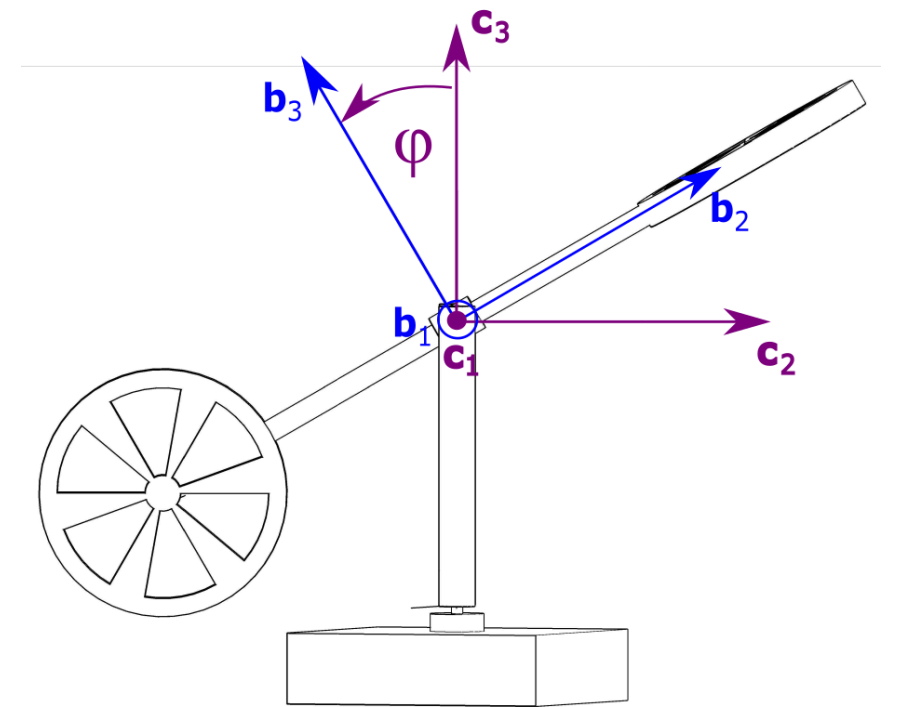



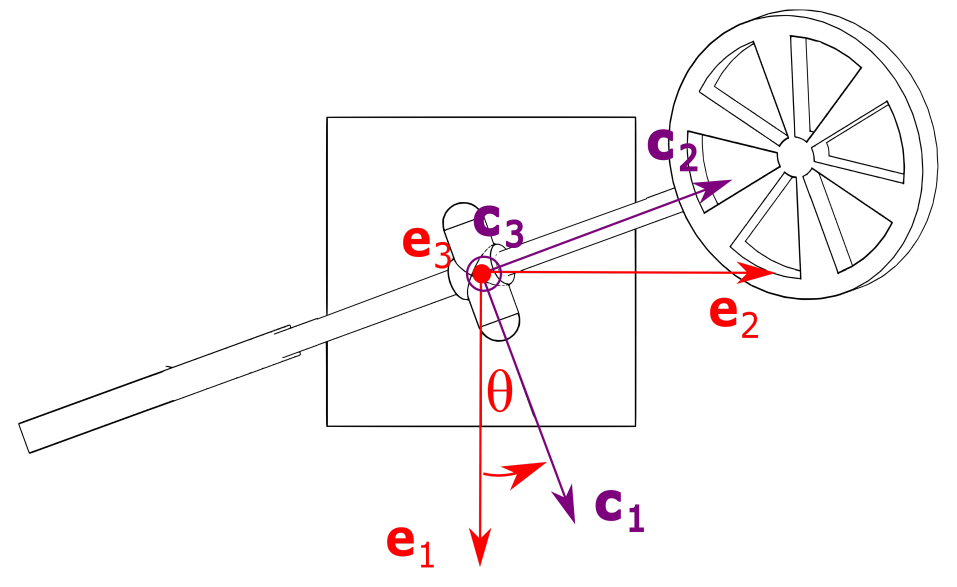

**Frame Definitions**

Let $\mathbf{e} = \{e_1, e_2, e_3\}$ denote the **Earth-fixed inertial frame**, which is stationary and used as the reference frame. The origin of this frame is located at the pivot point of the system.

Let $\mathbf{c} = \{c_1, c_2, c_3\}$ be an **intermediate orthonormal frame** attached to the vertical support structure. This frame rotates about the vertical axis $e_3$, representing the **yaw** motion of the system. Thus:
$$\mathbf{c} = \mathbf{e} R_3(\theta)$$
where $\theta$ is the yaw angle and:
$$R_3(\theta)=
\begin{bmatrix}
\cos\theta & -\sin\theta & 0\\
\sin\theta & \cos\theta & 0\\
0 & 0 & 1
\end{bmatrix}$$

Let $\mathbf{b} = \{b_1, b_2, b_3\}$ be the **body-fixed frame** attached to the twin rotor beam. The origin coincides with that of frame $\mathbf{c}$, and the axis $b_1 \equiv c_1$ is aligned with the pivot axis. The frame $\mathbf{b}$ rotates relative to $\mathbf{c}$ about this axis, representing the **pitch** motion of the beam. Hence:
$$\mathbf{b} = \mathbf{c} R_1(\phi)$$
where $\phi$ is the pitch angle and:
$$R_1(\phi)=
\begin{bmatrix}
1 & 0 & 0\\
0 & \cos\phi & -\sin\phi\\
0 & \sin\phi & \cos\phi
\end{bmatrix}$$

By combining the above transformations, the orientation of the body frame with respect to the inertial frame is given by:
$$\mathbf{b} = \mathbf{e} R_3(\theta)R_1(\phi) = \mathbf{e}R$$
where the total rotation matrix $R$ is:
$$R = R_3(\theta)R_1(\phi)$$

**Physical Interpretation**
* $\theta$: rotation about the fixed vertical axis $e_3$ (**yaw motion**)
* $\phi$: rotation about the moving axis $b_1 \equiv c_1$ (**pitch motion**)
* **Frame $\mathbf{c}$**: captures yaw motion.
* **Frame $\mathbf{b}$**: captures full body orientation (yaw + pitch).

## **Task 1 - Dynamics of the Twin Rotor System**

### **Angular Velocity**

From the previous section, the orientation of the body frame relative to the inertial frame is:
$$R = R_3(\theta)R_1(\phi)$$

Substituting the rotation matrices:
$$R = \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\phi & -\sin\phi \\ 0 & \sin\phi & \cos\phi \end{bmatrix}$$

Multiplying the matrices yields:
$$R = \begin{bmatrix} \cos\theta & -\cos\phi\sin\theta & \sin\phi\sin\theta \\ \sin\theta & \cos\phi\cos\theta & -\sin\phi\cos\theta \\ 0 & \sin\phi & \cos\phi \end{bmatrix}$$

**Time Derivative of the Rotation Matrix**

To find the velocity of the orientation, we differentiate $R$:
$$\dot{R} = \dot{R}_3 R_1 + R_3 \dot{R}_1$$

Using rigid-body kinematics where $\dot{R}_i = R_i \hat{\Omega}_i$:
$$\dot{R} = R_3 \hat{\Omega}_3 R_1 + R_3 R_1 \hat{\Omega}_1$$

Factoring out $R = R_3 R_1$:
$$\dot{R} = R \left( R_1^T \hat{\Omega}_3 R_1 + \hat{\Omega}_1 \right)$$

Comparing this with the standard form $\dot{R} = R\hat{\Omega}$, we identify the body-frame angular velocity tensor:
$$\hat{\Omega} = R_1^T \hat{\Omega}_3 R_1 + \hat{\Omega}_1$$


**Angular Velocity of the Twin Rotor System**

Step 1: Define individual angular velocities
*   **Rotation about $c_3 = e_3$ (Yaw):** $\Omega_3 = \dot{\theta} e_3$
*   **Rotation about $b_1$ (Pitch):** $\Omega_1 = \dot{\phi} b_1$

Step 2: Express in the body frame
We must transform $\Omega_3$ into the body frame using $R_1^T$:
$$R_1^T e_3 = \begin{bmatrix} 0 \\ \sin\phi \\ \cos\phi \end{bmatrix}$$

Thus, the yaw contribution in the body frame is:
$$\Omega_3^{(body)} = \dot{\theta} \begin{bmatrix} 0 \\ \sin\phi \\ \cos\phi \end{bmatrix}$$

Step 3: Combined Vector
$$\Omega = \Omega_1 + \Omega_3^{(body)} = \begin{bmatrix} \dot{\phi} \\ 0 \\ 0 \end{bmatrix} + \dot{\theta} \begin{bmatrix} 0 \\ \sin\phi \\ \cos\phi \end{bmatrix}$$

**Final Angular Velocity Expression**
$$\boxed{\Omega = \begin{bmatrix} \dot{\phi} \\ \dot{\theta}\sin\phi \\ \dot{\theta}\cos\phi \end{bmatrix}}$$

Physical Interpretation
*   $\dot{\phi}$: Direct rotation about the beam axis ($b_1$).
*   $\dot{\theta} \sin\phi$: Lateral component of yaw as the beam tilts.
*   $\dot{\theta} \cos\phi$: Vertical component of yaw.

### **Torque Equation**

In the body frame $\mathbf{b}$, the angular momentum is defined as:
$$\Pi = \mathbb{I}\Omega$$
where:
*   $\mathbb{I} = \text{diag}(I_1, I_2, I_3)$ is the inertia tensor.
*   $\Omega$ is the body angular velocity.
*   This originates from the fundamental rigid body definition $\sum (r \times mv)$.

Newton’s laws must be applied in the inertial (spatial) frame. Thus, we define:
$${\pi = R \Pi = R \mathbb{I} \Omega}$$


By Newton's Law, the rate of change of spatial angular momentum equals the sum of external torques:
$${\dot{\pi} = \sum \tau_{\text{ext}}}$$
For the twin rotor system, this is split into:
$$\boxed{\dot{\pi} = \tau_u + \tau_e}$$
where $\tau_u$ is the actuator torque and $\tau_e$ is the constraint (reaction) torque.

$\dot{\pi}$ is obtained by differentiating $\pi = R \mathbb{I} \Omega$. By product rule:
$$\dot{\pi} = \frac{d}{dt}(R \mathbb{I} \Omega)$$
$$\dot{\pi} = \dot{R} \mathbb{I} \Omega + R I \dot{\Omega}$$


Using the kinematic identity derived earlier, $\dot{R} = R \hat{\Omega}$:
$$\dot{\pi} = (R \hat{\Omega}) \mathbb{I} \Omega + R \mathbb{I} \dot{\Omega}$$
$${\dot{\pi} = R \left( \hat{\Omega} \mathbb{I} \Omega + I \dot{\Omega} \right)}$$

Using the identity $\hat{\Omega} x = \Omega \times x$, the first term becomes:
$$\hat{\Omega} \mathbb{I} \Omega = \Omega \times (\mathbb{I} \Omega)$$
Substituting this back:
$$\boxed{\dot{\pi} = R \left( \mathbb{I} \dot{\Omega} + \Omega \times (\mathbb{I} \Omega) \right)}$$


Multiplying both sides by $R^T$ (noting that $R^T \dot{\pi} = \dot{\Pi}$ in the rotating frame):
$$R^T \dot{\pi} = \mathbb{I} \dot{\Omega} + \Omega \times (\mathbb{I} \Omega)$$
$$\boxed{\dot{\Pi} = \mathbb{I} \dot{\Omega} + \Omega \times (\mathbb{I} \Omega)}$$


By substituting the torque components $\dot{\Pi} = T_u + T_e$ (expressed in the body frame):
$$\boxed{T_u + T_e = \mathbb{I} \dot{\Omega} + \Omega \times (\mathbb{I} \Omega)}$$


The terms in the above equation represents,

$\mathbb{I}\dot{\Omega}$ - Inertia (Angular acceleration component)

$\Omega \times (\mathbb{I}\Omega)$ - Gyroscopic Coupling (Effect of rotating about multiple axes)

$T_u$ - Actuator Torque (Control input)

$T_e$ - Constraint Reaction (Forces from the pivot/support)


**1. Actuator Torque ($T_u$) in the Body Frame**

The two rotors produce thrusts that are tilted relative to the beam's main axes:
*   $u_1$: Thrust from Rotor 1 at angle $\alpha$ to a reference plane.
*   $u_2$: Thrust from Rotor 2 at angle $\beta$ to the same reference plane.

The two propelers of the Twin Rotor System in the laboratory are arranged $\alpha - \beta = 90°$ to each other.<br>
The thrusts create components along the body-fixed axes $b_1$ (x-axis) and $b_3$ (z-axis).

By Rotor 1,
$$ \text{x-component: } u_1 \cos\alpha, \quad \text{z-component: } u_1 \sin\alpha $$

By Rotor 2,
$$ \text{x-component: } -u_2 \cos\beta, \quad \text{z-component: } -u_2 \sin\beta $$

In the body frame, the actuator torque vector is:
$${ T_u = \begin{bmatrix} u_1 \cos\alpha - u_2 \cos\beta \\ 0 \\ u_1 \sin\alpha - u_2 \sin\beta \end{bmatrix} }$$

**Note:** The middle component ($b_2$) is zero because rotation about the $b_2$ axis is not actuated in this mechanical configuration.

**2. Actuator Torque in the Spatial Frame**

To apply these to the global dynamics, we transform the body-frame torque using the rotation matrix $R$:
$${\tau_u = R T_u}$$
$${\tau_u = R \begin{bmatrix} u_1 \cos\alpha - u_2 \cos\beta \\ 0 \\ u_1 \sin\alpha - u_2 \sin\beta \end{bmatrix}}$$
<br>

**3. Constraint Torque ($T_e$) in the Body Frame**

The system is mechanically constrained and cannot rotate freely about the $b_2$ axis. A reaction (constraint) torque appears to enforce this holonomic constraint.

Using the torque equation derived previously:
$$T_u + T_e = \mathbb{I}\dot{\Omega} + \Omega \times (\mathbb{I}\Omega)$$
We isolate the reaction component $T_2$ acting along the $b_2$ axis:
$${T_2 = e_2^T \left( \mathbb{I}\dot{\Omega} + \Omega \times (\mathbb{I}\Omega) \right)}$$


**4. Constraint Torque in the Spatial Frame**

Similarly, the constraint torque is projected into the inertial frame:
$${\tau_e = R T_e}$$
$${\tau_e = R \begin{bmatrix} 0 \\ T_2 \\ 0 \end{bmatrix}}$$

## **Task 2 - Simulation of the system**

The above derived model is in a coordinate-free form:
$$\dot{R} = \hat{\Omega} R, \qquad \mathbb{I}\dot{\Omega} + \Omega \times (\mathbb{I}\Omega) = T_u + T_e$$

But, solvers require the system to be in the form $\dot{x} = f(x,t)$. To simulate using the angles $\theta$ (yaw) and $\phi$ (pitch), we define the state vector:
$$x = [\theta, \phi, \dot{\theta}, \dot{\phi}]^T$$

Therefore, we must obtain explicit expressions for **$\ddot{\theta}$** and **$\ddot{\phi}$** to obtain a first-order ODE system.

<br>

The body angular velocity is:
$$\Omega = \begin{bmatrix} \Omega_1 \\ \Omega_2 \\ \Omega_3 \end{bmatrix} = \begin{bmatrix} \dot{\phi} \\ \dot{\theta}\sin\phi \\ \dot{\theta}\cos\phi \end{bmatrix}$$

Time derivative (using the product rule):

  *  $\dot{\Omega}_1 = \ddot{\phi}$
  *  $\dot{\Omega}_2 = \ddot{\theta}\sin\phi + \dot{\theta}\dot{\phi}\cos\phi$
  *  $\dot{\Omega}_3 = \ddot{\theta}\cos\phi - \dot{\theta}\dot{\phi}\sin\phi$

So, the acceleration vector is:
$$\dot{\Omega} = \begin{bmatrix} \ddot{\phi} \\ \ddot{\theta}\sin\phi + \dot{\theta}\dot{\phi}\cos\phi \\ \ddot{\theta}\cos\phi - \dot{\theta}\dot{\phi}\sin\phi \end{bmatrix}$$


Let $\mathbb{I} = \text{diag}(I_1, I_2, I_3)$. Then:
$$\mathbb{I}\dot{\Omega} = \begin{bmatrix} I_1\ddot{\phi} \\ I_2(\ddot{\theta}\sin\phi + \dot{\theta}\dot{\phi}\cos\phi) \\ I_3(\ddot{\theta}\cos\phi - \dot{\theta}\dot{\phi}\sin\phi) \end{bmatrix}$$

For gyroscopic Term ($\Omega \times (\mathbb{I}\Omega)$),

Angular momentum <br>
$$\Pi = \mathbb{I}\Omega = \begin{bmatrix} I_1\dot{\phi} \\ I_2\dot{\theta}\sin\phi \\ I_3\dot{\theta}\cos\phi \end{bmatrix}$$

Then,
$$\Omega \times (\mathbb{I}\Omega) = \begin{bmatrix} (I_3 - I_2)\dot{\theta}^2 \sin\phi \cos\phi \\ (I_1 - I_3)\dot{\theta}\dot{\phi}\cos\phi \\ (I_2 - I_1)\dot{\theta}\dot{\phi}\sin\phi \end{bmatrix}$$

<br>

Substituting into $\mathbb{I}\dot{\Omega} + \Omega \times (\mathbb{I}\Omega) = T_u + T_e$:

1. Along $b_1$ (Pitch Dynamics):
$$I_1\ddot{\phi} + (I_3 - I_2)\dot{\theta}^2 \sin\phi \cos\phi = u_1\cos\alpha - u_2\cos\beta$$

2. Along $b_3$ (Yaw Dynamics):
$$I_3(\ddot{\theta}\cos\phi - \dot{\theta}\dot{\phi}\sin\phi) + (I_2 - I_1)\dot{\theta}\dot{\phi}\sin\phi = u_1\sin\alpha - u_2\sin\beta$$

<br>

### Solving for Accelerations:

$$\boxed{ \ddot{\phi} = \frac{1}{I_1} \left[ u_1\cos\alpha - u_2\cos\beta - (I_3 - I_2)\dot{\theta}^2 \sin\phi \cos\phi \right] }$$

<br>

$$\boxed{ \ddot{\theta} = \frac{ u_1\sin\alpha - u_2\sin\beta + (I_3 - I_2 + I_1)\dot{\theta}\dot{\phi}\sin\phi }{ I_3\cos\phi } }$$


In [2]:
import numpy as np
import plotly.graph_objects as go
from scipy.integrate import solve_ivp

# ===========================
# System Parameters
# ===========================
I1, I2, I3 = 1.0, 2.0, 1.5

alpha = 0.0                 # radians
beta  = np.pi / 2          # 90 degrees

# Constant thrust inputs (always positive)
u1 = 1.0
u2 = 0.8

# Geometry
L = 1.0     # beam length
R_prop = 0.2  # propeller radius

# ===========================
# Dynamics
# ===========================
def dynamics(t, state):
    theta, phi, dtheta, dphi = state

    cos_phi = np.cos(phi)
    if abs(cos_phi) < 1e-6:
        cos_phi = 1e-6

    sin_phi = np.sin(phi)

    ddphi = (1 / I1) * (
        u1 * np.cos(alpha)
        - u2 * np.cos(beta)
        - (I3 - I2) * (dtheta**2) * sin_phi * cos_phi
    )

    ddtheta = (
        u1 * np.sin(alpha)
        - u2 * np.sin(beta)
        + (I3 - I2 + I1) * dtheta * dphi * sin_phi
    ) / (I3 * cos_phi)

    return [dtheta, dphi, ddtheta, ddphi]

# ===========================
# Simulation
# ===========================
t_span = (0, 10)
t_eval = np.linspace(0, 10, 200)

y0 = [0.0, 0.2, 0.0, 0.0]

sol = solve_ivp(dynamics, t_span, y0, t_eval=t_eval)

theta_vals = sol.y[0]
phi_vals   = sol.y[1]

# ===========================
# Rotation Matrix
# ===========================
def get_rotation(theta, phi):
    Rz = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(phi), -np.sin(phi)],
        [0, np.sin(phi),  np.cos(phi)]
    ])
    return Rz @ Rx

# ===========================
# Create Propeller Circle
# ===========================
def create_circle(center, normal, radius=0.2, points=30):
    t = np.linspace(0, 2*np.pi, points)

    # Create perpendicular vectors
    if abs(normal[0]) < 0.9:
        v = np.cross(normal, [1,0,0])
    else:
        v = np.cross(normal, [0,1,0])
    v = v / np.linalg.norm(v)
    w = np.cross(normal, v)

    circle = center[:,None] + radius*(v[:,None]*np.cos(t) + w[:,None]*np.sin(t))
    return circle

# ===========================
# Animation Frames
# ===========================
frames = []

for i in range(len(t_eval)):
    theta = theta_vals[i]
    phi   = phi_vals[i]

    R = get_rotation(theta, phi)

    # Beam (along body y-axis)
    beam_local = np.array([[0, -L/2, 0], [0, L/2, 0]])
    beam = (R @ beam_local.T).T

    # Rotor positions
    p1 = beam[0]
    p2 = beam[1]

    # Rotor directions
    n1 = R @ np.array([1,0,0])   # b1 axis
    n2 = R @ np.array([0,0,1])   # b3 axis

    # Circles
    c1 = create_circle(p1, n1, R_prop)
    c2 = create_circle(p2, n2, R_prop)

    # Thrust vectors (orange)
    thrust_scale = 0.4
    t1_end = p1 + thrust_scale * n1
    t2_end = p2 - thrust_scale * n2

    frames.append(go.Frame(data=[
        # Beam
        go.Scatter3d(x=beam[:,0], y=beam[:,1], z=beam[:,2],
                     mode='lines', line=dict(width=6)),

        # Rotor 1
        go.Scatter3d(x=c1[0], y=c1[1], z=c1[2],
                     mode='lines'),

        # Rotor 2
        go.Scatter3d(x=c2[0], y=c2[1], z=c2[2],
                     mode='lines'),

        # Thrust arrows
        go.Scatter3d(x=[p1[0], t1_end[0]], y=[p1[1], t1_end[1]], z=[p1[2], t1_end[2]],
                     mode='lines', line=dict(width=5)),
        go.Scatter3d(x=[p2[0], t2_end[0]], y=[p2[1], t2_end[1]], z=[p2[2], t2_end[2]],
                     mode='lines', line=dict(width=5)),
    ]))

# ===========================
# Plot Figure
# ===========================
fig = go.Figure(
    data=frames[0].data,
    layout=go.Layout(
        title="Twin Rotor Animation",
        scene=dict(
            xaxis=dict(range=[-2,2]),
            yaxis=dict(range=[-2,2]),
            zaxis=dict(range=[-2,2]),
            aspectmode='cube'
        ),
        updatemenus=[dict(
            type="buttons",
            buttons=[
                dict(label="Play",
                     method="animate",
                     args=[None, {"frame": {"duration": 50, "redraw": True}}]),
                dict(label="Pause",
                     method="animate",
                     args=[[None], {"frame": {"duration": 0}}])
            ]
        )]
    ),
    frames=frames
)

fig.show()

In [3]:
import numpy as np
import plotly.graph_objects as go
from scipy.integrate import solve_ivp

# ===========================
# System Parameters
# ===========================
I1, I2, I3 = 1.0, 2.0, 1.5

alpha = 0.0
beta  = np.pi / 2

# Geometry
L = 1.0
R_prop = 0.2

# ===========================
# Time-Varying Inputs
# ===========================
def get_inputs(t):
    cycle_time = t % 9  # repeat every 9 seconds

    # 0–3s → yaw (u2 active)
    if cycle_time < 3:
        return 0.0, 1.0

    # 3–5s → stop
    elif cycle_time < 5:
        return 0.0, 0.0

    # 5–7s → pitch (u1 active)
    elif cycle_time < 7:
        return 1.0, 0.0

    # 7–9s → stop
    else:
        return 0.0, 0.0

# ===========================
# Dynamics
# ===========================
def dynamics(t, state):
    theta, phi, dtheta, dphi = state

    u1, u2 = get_inputs(t)

    cos_phi = np.cos(phi)
    if abs(cos_phi) < 1e-6:
        cos_phi = 1e-6

    sin_phi = np.sin(phi)

    ddphi = (1 / I1) * (
        u1 * np.cos(alpha)
        - u2 * np.cos(beta)
        - (I3 - I2) * (dtheta**2) * sin_phi * cos_phi
    )

    ddtheta = (
        u1 * np.sin(alpha)
        - u2 * np.sin(beta)
        + (I3 - I2 + I1) * dtheta * dphi * sin_phi
    ) / (I3 * cos_phi)

    return [dtheta, dphi, ddtheta, ddphi]

# ===========================
# Simulation
# ===========================
t_span = (0, 18)
t_eval = np.linspace(0, 18, 300)

y0 = [0.0, 0.2, 0.0, 0.0]

sol = solve_ivp(dynamics, t_span, y0, t_eval=t_eval)

theta_vals = sol.y[0]
phi_vals   = sol.y[1]

# ===========================
# Rotation Matrix
# ===========================
def get_rotation(theta, phi):
    Rz = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(phi), -np.sin(phi)],
        [0, np.sin(phi),  np.cos(phi)]
    ])
    return Rz @ Rx

# ===========================
# Circle Generator
# ===========================
def create_circle(center, normal, radius=0.2, points=30):
    t = np.linspace(0, 2*np.pi, points)

    if abs(normal[0]) < 0.9:
        v = np.cross(normal, [1,0,0])
    else:
        v = np.cross(normal, [0,1,0])

    v = v / np.linalg.norm(v)
    w = np.cross(normal, v)

    circle = center[:,None] + radius*(v[:,None]*np.cos(t) + w[:,None]*np.sin(t))
    return circle

# ===========================
# Animation Frames
# ===========================
frames = []

for i in range(len(t_eval)):
    theta = theta_vals[i]
    phi   = phi_vals[i]

    R = get_rotation(theta, phi)

    # Beam
    beam_local = np.array([[0, -L/2, 0], [0, L/2, 0]])
    beam = (R @ beam_local.T).T

    p1, p2 = beam

    # Body axes
    n1 = R @ np.array([1,0,0])
    n2 = R @ np.array([0,0,1])

    # Propellers
    c1 = create_circle(p1, n1, R_prop)
    c2 = create_circle(p2, n2, R_prop)

    # Thrust directions
    thrust_scale = 0.4
    t1_end = p1 + thrust_scale * n1
    t2_end = p2 - thrust_scale * n2

    # Vertical axis (inertial z-axis)
    vertical_axis = np.array([[0,0,-1.5],[0,0,1.5]])

    frames.append(go.Frame(data=[
        # Vertical axis
        go.Scatter3d(x=vertical_axis[:,0], y=vertical_axis[:,1], z=vertical_axis[:,2],
                     mode='lines', line=dict(width=4, dash='dash')),

        # Beam
        go.Scatter3d(x=beam[:,0], y=beam[:,1], z=beam[:,2],
                     mode='lines', line=dict(width=6)),

        # Rotors
        go.Scatter3d(x=c1[0], y=c1[1], z=c1[2], mode='lines'),
        go.Scatter3d(x=c2[0], y=c2[1], z=c2[2], mode='lines'),

        # Thrust
        go.Scatter3d(x=[p1[0], t1_end[0]], y=[p1[1], t1_end[1]], z=[p1[2], t1_end[2]],
                     mode='lines', line=dict(width=5, color='orange')),
        go.Scatter3d(x=[p2[0], t2_end[0]], y=[p2[1], t2_end[1]], z=[p2[2], t2_end[2]],
                     mode='lines', line=dict(width=5, color='orange')),
    ]))

# ===========================
# Plot
# ===========================
fig = go.Figure(
    data=frames[0].data,
    layout=go.Layout(
        title="Twin Rotor Motion (Yaw + Pitch Cycles)",
        scene=dict(
            xaxis=dict(range=[-2,2]),
            yaxis=dict(range=[-2,2]),
            zaxis=dict(range=[-2,2]),
            aspectmode='cube'
        ),
        updatemenus=[dict(
            type="buttons",
            buttons=[
                dict(label="Play",
                     method="animate",
                     args=[None, {"frame": {"duration": 60, "redraw": True}}]),
                dict(label="Pause",
                     method="animate",
                     args=[[None], {"frame": {"duration": 0}}])
            ]
        )]
    ),
    frames=frames
)

fig.show()